In [47]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams['font.family'] = 'Times New Roman'

In [48]:
reporting_directory_path = "app/analytical-backend/data/08_reporting/"
simulation_output_directory = "simulation_output"

In [ ]:
## Data loading

all_vintage_data = pd.read_csv("app/analytical-backend/data/0_source/00_extract_vintagedata.csv", decimal=",")
current_vintage_data = pd.read_csv(os.path.join(reporting_directory_path, "PCEC96.csv"))
last_sim = pd.read_excel(os.path.join(reporting_directory_path, simulation_output_directory, "sim202204.xlsx"), sheet_name="Nowcast Browser – Base")
vix_d = pd.read_csv("VIXCLS.csv", index_col=0)
vix_d.index = pd.to_datetime(vix_d.index)
vix_m = vix_d.resample('M').last()
vix_m.index = vix_m.index.to_period('M').to_timestamp(how='start')

/var/folders/3k/vh6dl_9j30z3n567nqndm7tw0000gp/T/ipykernel_6509/913246488.py:3: DtypeWarning: Columns (2,8,9,10,11) have mixed types. Specify dtype option on import or set low_memory=False.
  all_vintage_data = pd.read_csv("app/analytical-backend/data/0_source/00_extract_vintagedata.csv", decimal=",")
/var/folders/3k/vh6dl_9j30z3n567nqndm7tw0000gp/T/ipykernel_6509/913246488.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  vix_m = vix_d.resample('M').last()


In [50]:
simulation_outputs = []
for fname in os.listdir(os.path.join(reporting_directory_path, simulation_output_directory)):
    if not fname.endswith("xlsx"): continue
    fpath = os.path.join(reporting_directory_path, simulation_output_directory, fname)

    ts = pd.read_excel(fpath, sheet_name="Nowcast Browser – Base")
    cards = pd.read_excel(fpath, sheet_name="Cards")
    row = ts.loc[ts["Actual"].isna()]
    simulation_outputs.append({
        "ReferenceDate": row["Reference Date"].item(),
        "Predicted": row["Predicted"].item(),
        "ARIMA": cards.loc[cards["Card"] == "ARIMA"]["Value"].item(),
        "VAR": cards.loc[cards["Card"] == "VAR"]["Value"].item(),
        })

In [ ]:
## Data processing

### Early estimates
all_vintage_data = all_vintage_data.loc[all_vintage_data["VariableCode"] == "PCEC96"]
cols = ["ReferenceDate", "PublicationDate"]
all_vintage_data[cols] = all_vintage_data[cols].apply(pd.to_datetime)
mask = all_vintage_data.groupby("ReferenceDate").agg({"PublicationDate": "min"})
early_estimates = pd.merge(all_vintage_data, mask.reset_index(), on=cols, how="right")
early_estimates = early_estimates.set_index("ReferenceDate").sort_index()
early_estimates.index = early_estimates.index.strftime("%Y-%m-%d")

### Current-vintage data
current_vintage_data["observation_date"] = pd.to_datetime(current_vintage_data["observation_date"])
current_vintage_data = current_vintage_data.rename(columns={
    "observation_date": "ReferenceDate",
    "PCEC96": "VariableValue"
})
current_vintage_data = current_vintage_data.set_index("ReferenceDate").sort_index()
current_vintage_data.index = current_vintage_data.index.strftime("%Y-%m-%d")

### Predictions
simulation_df = pd.DataFrame(simulation_outputs)
simulation_df = simulation_df.set_index("ReferenceDate").sort_index()
simulation_df.index = simulation_df.index.strftime("%Y-%m-%d")

In [52]:
## Residual Learning (Meta Model)

pred_act = pd.merge(
    early_estimates[["VariableValue"]],
    simulation_df, 
    how="left",
    left_index=True,
    right_index=True
)

In [53]:
## Preparing data to plot
pred_act = pred_act.dropna(subset=["Predicted"])
nowcast_df = pred_act[["Predicted"]]

idx = pd.date_range(start=nowcast_df.index.min(), end=nowcast_df.index.max(), freq='MS')
idx = idx.strftime("%Y-%m-%d")

df_plt = pd.concat([
    current_vintage_data.loc[idx].rename(columns={"VariableValue": "CurrentRelease"}), 
    early_estimates[["VariableValue"]].rename(columns={"VariableValue": "FirstRelease"}).loc[idx], 
    nowcast_df.loc[idx]
    ], axis=1)

df_plt.index = pd.to_datetime(df_plt.index)
df_plt = df_plt.merge(vix_m, left_index=True, right_index=True, how="left")

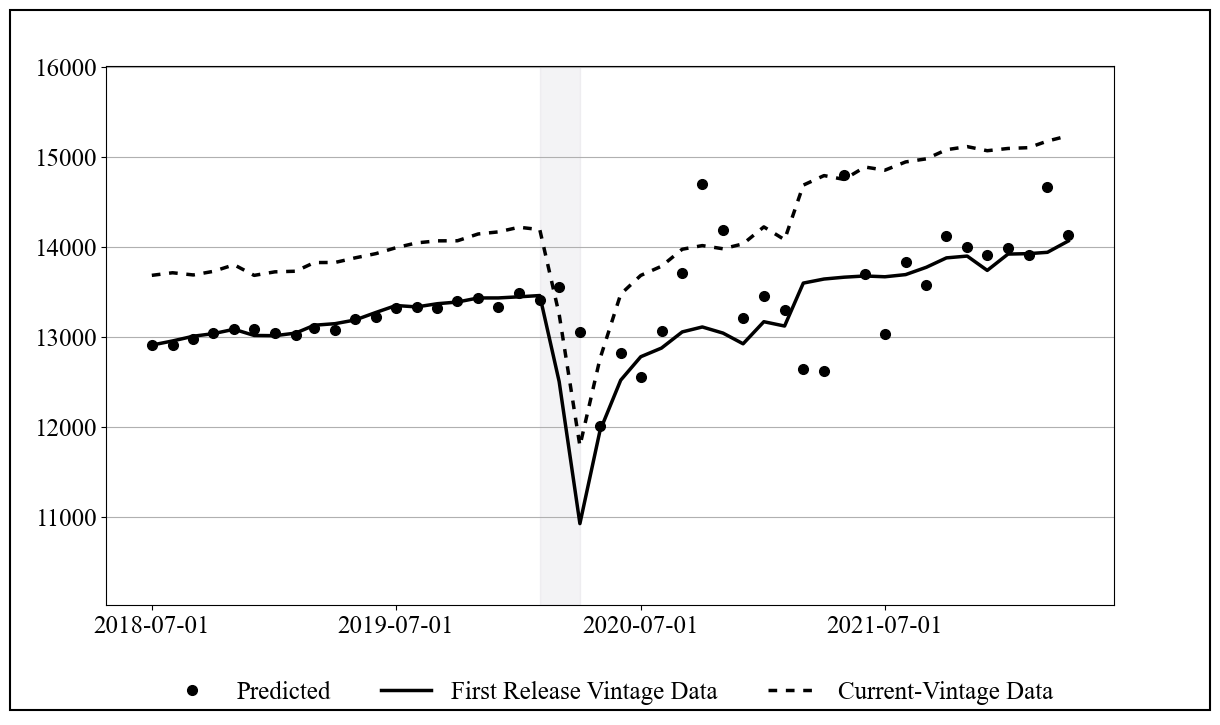

In [ ]:
## Plot 1.: The first release, current-vintage actuals along with predictions

# Assuming df_plt contains the data and you want to adjust the x-axis labels
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Plotting the 'CurrentRelease' data
line, = ax.plot(df_plt["CurrentRelease"], color='black', label='Current-Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)
line.set_dashes([2.5, 2.5])

# Plotting the 'Nowcast' data
ax.plot(df_plt["Predicted"], color='black', label='Predicted', linestyle='-', marker='o', markersize=7, linewidth=0)
ax.grid(True, axis='y')

# Axes
cols = ['CurrentRelease', 'FirstRelease', 'Predicted']
y_range = [df_plt[cols].min().min()-900, df_plt[cols].max().max()+780]
ax.set_ylim(y_range)
for label in ax.get_yticklabels():
    label.set_fontsize(18)

ax.set_xticks(df_plt.index[::12])
ax.set_xticklabels(df_plt.index.strftime('%Y-%m-%d')[::12], fontsize=18)  # Format as year

# Plotting the 'FirstRelease' data with dashed line
ax.plot(df_plt["FirstRelease"], color='black', label='First Release Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)

ax.fill_between(
        x=df_plt.loc["2020-02-01":"2020-04-01"].index, 
        y1=y_range[0], 
        y2=y_range[1],
        color="#938BA1",
        alpha=0.1)

# Adding legend inside the plot
handles, labels = ax.get_legend_handles_labels()
desired_order = [
    "Predicted",
    "First Release Vintage Data",
    "Current-Vintage Data"
    ]
order = [labels.index(label) for label in desired_order]
ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc='upper center',
    fontsize=18,
    bbox_to_anchor=(0.5, -0.1),  # X center, Y below axis (tweak -0.15 as needed)
    ncol=3,  # Put items in one row (adjust based on how many items you have)
    frameon=False  # Optional: remove border
)

fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.15)

# Add outer frame (border)
frame = patches.Rectangle(
    (0, 0), 1, 1, transform=fig.transFigure,  # full figure (not just axes)
    fill=False,
    edgecolor='black',
    linewidth=1.5
)
fig.patches.append(frame)

plt.show()


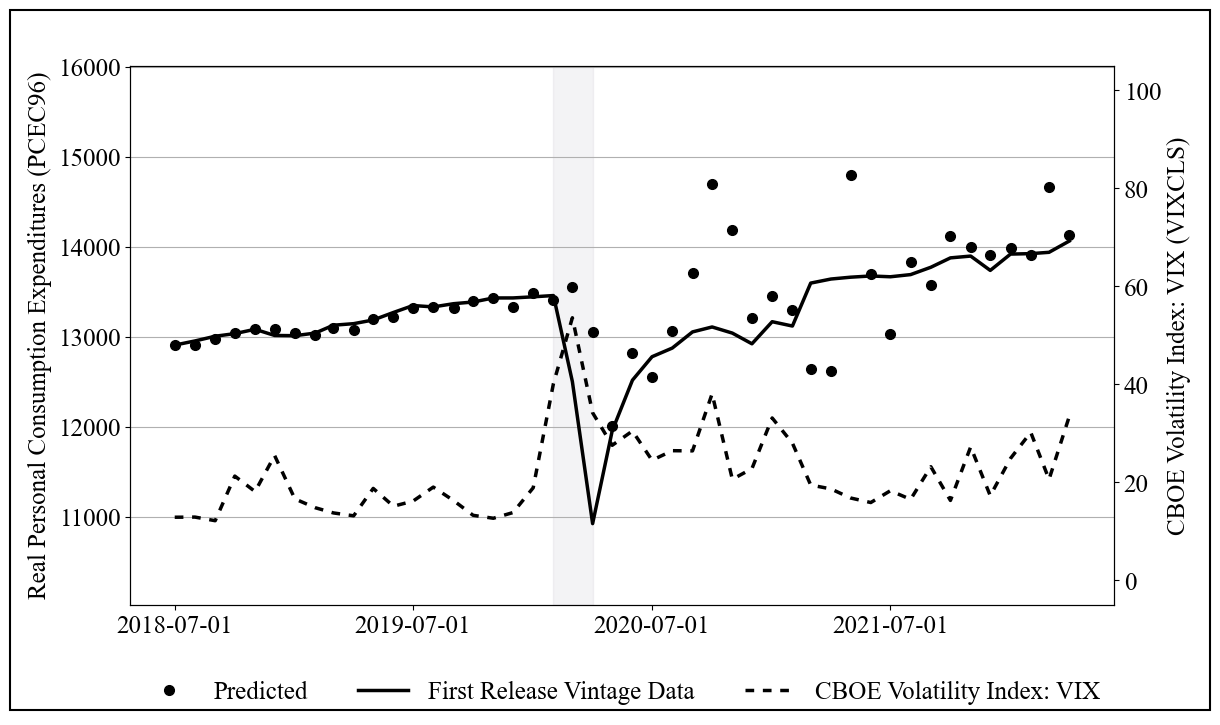

In [ ]:
## Plot 2.: The first release actuals, predictions and volatility index

# Assuming df_plt contains the data and you want to adjust the x-axis labels
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Plotting the 'Nowcast' data
ax.plot(df_plt["Predicted"], color='black', label='Predicted', linestyle='-', marker='o', markersize=7, linewidth=0)
ax.set_ylabel('Real Personal Consumption Expenditures (PCEC96)', fontsize=18)
ax.grid(True, axis='y')

# Axes
cols = ['CurrentRelease', 'FirstRelease', 'Predicted']
y_range = [df_plt[cols].min().min()-900, df_plt[cols].max().max()+780]
ax.set_ylim(y_range)
for label in ax.get_yticklabels():
    label.set_fontsize(18)

ax.set_xticks(df_plt.index[::12])
ax.set_xticklabels(df_plt.index.strftime('%Y-%m-%d')[::12], fontsize=18)  # Format as year

# Plotting the 'FirstRelease' data with dashed line
ax.plot(df_plt["FirstRelease"], color='black', label='First Release Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)

ax.fill_between(
        x=df_plt.loc["2020-02-01":"2020-04-01"].index, 
        y1=y_range[0], 
        y2=y_range[1],
        color="#938BA1",
        alpha=0.1)

ax2 = ax.twinx()
ax2.set_ylim([-5, 105])
ax2.set_ylabel('CBOE Volatility Index: VIX (VIXCLS)', fontsize=18)
ax2.tick_params(axis='y', labelsize=18)
line, = ax2.plot(df_plt["VIXCLS"], color='black', label='CBOE Volatility Index: VIX', linestyle='-', marker='o', markersize=0, linewidth=2.5)
line.set_dashes([2.5, 2.5])

# Adding legend inside the plot
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine both
handles = handles1 + handles2
labels = labels1 + labels2

# Ensure desired order
desired_order = [
    "Predicted",
    "First Release Vintage Data",
    "CBOE Volatility Index: VIX"
]
order = [labels.index(label) for label in desired_order if label in labels]

ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc='upper center',
    fontsize=18,
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False
)

fig.subplots_adjust(left=0.1, right=0.92, top=0.92, bottom=0.15)

# Add outer frame (border)
frame = patches.Rectangle(
    (0, 0), 1, 1, transform=fig.transFigure,  # full figure (not just axes)
    fill=False,
    edgecolor='black',
    linewidth=1.5
)
fig.patches.append(frame)

plt.show()


In [56]:
## Residual Learning (Meta Model)

# 1. Compute Relevant Differences and Lags
# Key transformations are created to assess the behavior of both predicted and observed changes:
#   * Predicted - Lag: the forecasted month-over-month (MoM) change.
#   * Nowcast Change (MoM): first difference of predicted values (forecast dynamics).
#   * Lag(Actual Change (MoM)): observed MoM change from one period prior, used as a proxy for recent trend.

pred_act["Lag"] = pred_act["VariableValue"].shift()

pred_act["Predicted - Lag"] = pred_act["Predicted"] - pred_act["Lag"]
pred_act["Nowcast Change (MoM)"] = pred_act["Predicted"] - pred_act["Predicted"].shift()
pred_act["Lag(Actual Change (MoM))"] = (pred_act["VariableValue"] - pred_act["Lag"]).shift()
# Assume we're working with the lagged actual MoM changes
x = pred_act["Lag(Actual Change (MoM))"]

# 2. Estimate Exponentially Weighted IQR Bounds
# To dynamically capture recent volatility regimes, exponentially weighted quantiles are computed over a rolling window. This enables time-adaptive bounds that are more responsive than expanding windows.

# Apply exponentially weighted percentiles in a rolling way within the window
window = 6  # or more if you want smoother behavior
def ew_quantile(series, q, com=2):
    weights = np.exp(np.linspace(-1., 0., len(series)) / com)
    weights /= weights.sum()
    print(weights)
    return np.dot(np.sort(series), np.sort(weights))

pred_act["EW25th"] = x.rolling(window).apply(lambda s: ew_quantile(s, 0.25), raw=False)
pred_act["EW75th"] = x.rolling(window).apply(lambda s: ew_quantile(s, 0.75), raw=False)
pred_act["EWIQR"] = pred_act["EW75th"] - pred_act["EW25th"]

# 3. Define Adaptive Forecast Bounds
# Using the estimated interquartile range (EWIQR), economically plausible lower and upper bounds for predicted MoM changes are defined:
iqrs = 1.5
pred_act["Lower"] = pred_act["EW25th"] - iqrs * pred_act["EWIQR"]
pred_act["Upper"] = pred_act["EW75th"] + iqrs * pred_act["EWIQR"]

[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.19084416 0.21091542]
[0.12792667 0.14138083 0.15624998 0.17268294 0.1

In [57]:
# 4. Define Relative Change Threshold
# To account for scale and prevent false positives on large-level indicators, a relative change threshold is computed using the 90th percentile of past relative MoM changes:
rel_change = (pred_act["Lag(Actual Change (MoM))"] / pred_act["Lag"]).abs()
rel_thresh = rel_change.rolling(6).quantile(0.9)  # adaptively high

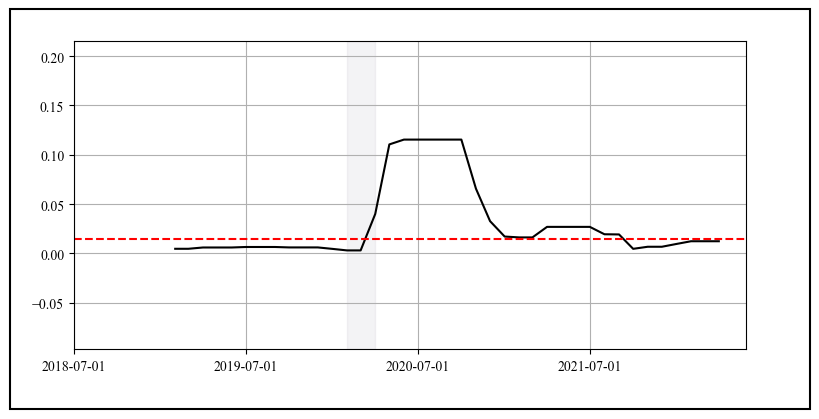

In [67]:
rel_thresh.index = pd.to_datetime(rel_thresh.index)
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

# Plotting rel_thresh
ax.plot(rel_thresh, color='black', label='rel_thresh', linestyle='-')

ax.axhline(y=0.015, color='red', linestyle='--')

# Optional: add a filled region if desired
ax.fill_between(
    x=rel_thresh.loc["2020-02-01":"2020-04-01"].index,
    y1=rel_thresh.min() - 0.1,
    y2=rel_thresh.max() + 0.1,
    color="#938BA1",
    alpha=0.1
)
# Axes styling
ax.set_ylim([rel_thresh.min() - 0.1, rel_thresh.max() + 0.1])

ax.set_xticks(rel_thresh.index[::12])
ax.set_xticklabels(rel_thresh.index.strftime('%Y-%m-%d')[::12])

ax.grid(True)

# Add outer frame (border)
frame = patches.Rectangle(
    (0, 0), 1, 1, transform=fig.transFigure,
    fill=False,
    edgecolor='black',
    linewidth=1.5
)
fig.patches.append(frame)

fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.15)
plt.show()

In [68]:
# 5. Flag Implausible Predictions
# A prediction is flagged as implausible if it:
#     * Falls outside the adaptive volatility bounds, and
#     * Exceeds a historically high relative MoM change threshold.
rel_thresh.index = rel_thresh.index.strftime("%Y-%m-%d")

pred_act["Flag"] = (
    # (~pred_act["Predicted - Lag"].between(pred_act["Lower"], pred_act["Upper"])) &
    ((pred_act["Predicted - Lag"]/pred_act["Lag"]).abs() > np.maximum(rel_thresh, 0.015))
)
print(pred_act["Flag"].shape, pred_act["Flag"].sum())

# 6. Adjust Implausible Forecasts with Naive Directional Proxy
# Flagged predictions are corrected using a directional heuristic:
#     * The sign of the model’s predicted change is retained (up/down).
#     * The magnitude is substituted with the absolute recent actual MoM change.

adjusted_nowcast = pred_act["Lag"] + (np.sign(pred_act["Nowcast Change (MoM)"])) * (pred_act["Lag(Actual Change (MoM))"]).abs()
pred_act["Nowcast"] = np.where(
    pred_act["Flag"],
    adjusted_nowcast,
    pred_act["Predicted"]
    )

(46,) 11


In [69]:
## Preparing data to plot
pred_act = pred_act.dropna(subset=["Predicted"])
nowcast_df = pred_act[["Nowcast", "Flag"]]

idx = pd.date_range(start=nowcast_df.index.min(), end=nowcast_df.index.max(), freq='MS')
idx = idx.strftime("%Y-%m-%d")

df_plt = pd.concat([
    current_vintage_data.loc[idx].rename(columns={"VariableValue": "CurrentRelease"}), 
    early_estimates[["VariableValue"]].rename(columns={"VariableValue": "FirstRelease"}).loc[idx], 
    nowcast_df.loc[idx]
    ], axis=1)

df_plt.index = pd.to_datetime(df_plt.index)
df_plt = df_plt.merge(vix_m, left_index=True, right_index=True, how="left")

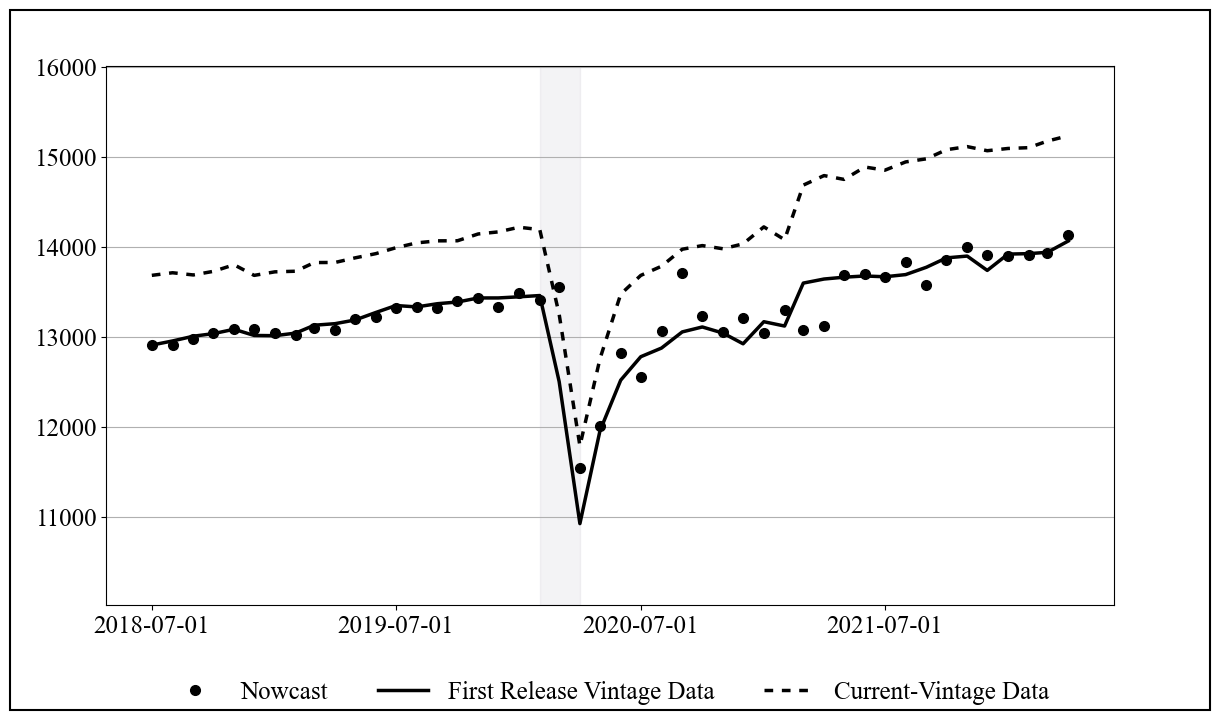

In [71]:
## Plot 1.: The first release, current-vintage actuals along with adjusted predictions

# Assuming df_plt contains the data and you want to adjust the x-axis labels
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Plotting the 'CurrentRelease' data
line, = ax.plot(df_plt["CurrentRelease"], color='black', label='Current-Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)
line.set_dashes([2.5, 2.5])

# Plotting the 'Nowcast' data
ax.plot(df_plt["Nowcast"], color='black', label='Nowcast', linestyle='-', marker='o', markersize=7, linewidth=0)
ax.grid(True, axis='y')

# Axes
cols = ['CurrentRelease', 'FirstRelease', 'Nowcast']
y_range = [df_plt[cols].min().min()-900, df_plt[cols].max().max()+780]
ax.set_ylim(y_range)
for label in ax.get_yticklabels():
    label.set_fontsize(18)

ax.set_xticks(df_plt.index[::12])
ax.set_xticklabels(df_plt.index.strftime('%Y-%m-%d')[::12], fontsize=18)  # Format as year

# Plotting the 'FirstRelease' data with dashed line
ax.plot(df_plt["FirstRelease"], color='black', label='First Release Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)

ax.fill_between(
        x=df_plt.loc["2020-02-01":"2020-04-01"].index, 
        y1=y_range[0], 
        y2=y_range[1],
        color="#938BA1",
        alpha=0.1)

# Adding legend inside the plot
handles, labels = ax.get_legend_handles_labels()
desired_order = ["Nowcast", "First Release Vintage Data", "Current-Vintage Data"]
order = [labels.index(label) for label in desired_order]
ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc='upper center',
    fontsize=18,
    bbox_to_anchor=(0.5, -0.1),  # X center, Y below axis (tweak -0.15 as needed)
    ncol=3,  # Put items in one row (adjust based on how many items you have)
    frameon=False  # Optional: remove border
)

fig.subplots_adjust(left=0.08, right=0.92, top=0.92, bottom=0.15)

# Add outer frame (border)
frame = patches.Rectangle(
    (0, 0), 1, 1, transform=fig.transFigure,  # full figure (not just axes)
    fill=False,
    edgecolor='black',
    linewidth=1.5
)
fig.patches.append(frame)

# # Tight layout so legend doesn't get cut off
# plt.tight_layout()

plt.show()


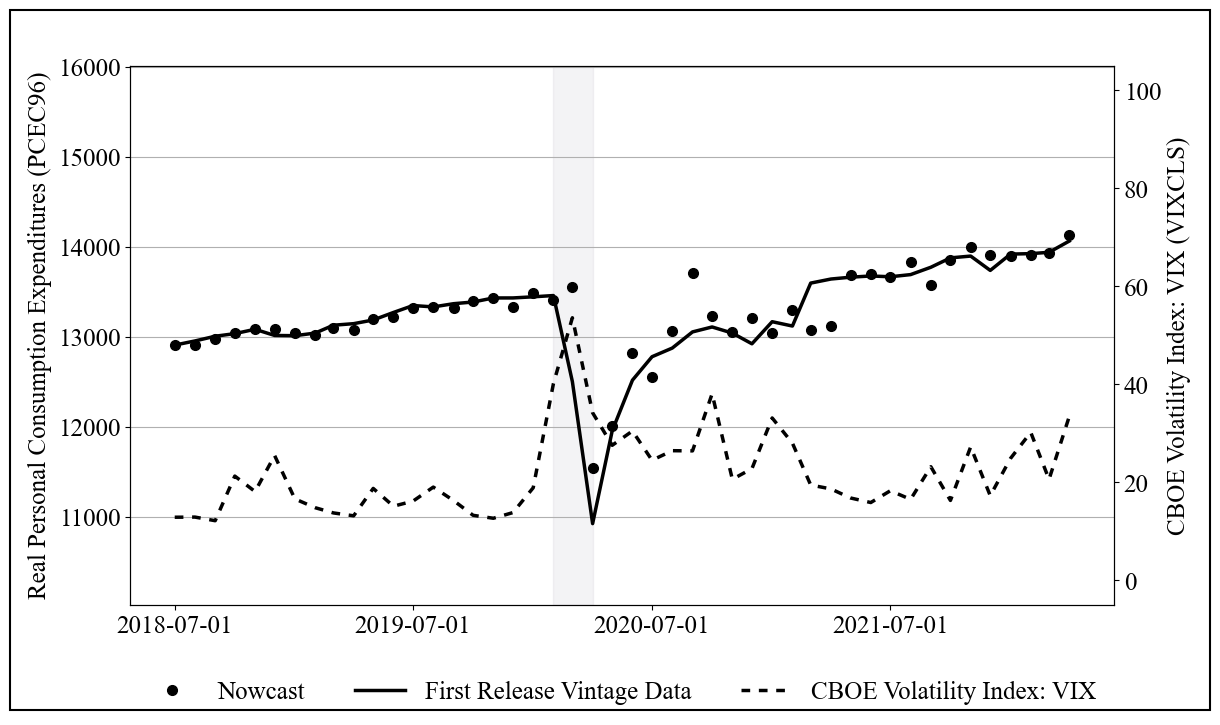

In [72]:
## Plot 2.: The first release actuals, predictions and volatility index

# Assuming df_plt contains the data and you want to adjust the x-axis labels
fig, ax = plt.subplots(1, 1, figsize=(12, 7))

# Plotting the 'Nowcast' data
ax.plot(df_plt["Nowcast"], color='black', label='Nowcast', linestyle='-', marker='o', markersize=7, linewidth=0)
ax.set_ylabel('Real Personal Consumption Expenditures (PCEC96)', fontsize=18)
ax.grid(True, axis='y')

# Axes
cols = ['CurrentRelease', 'FirstRelease', 'Nowcast']
y_range = [df_plt[cols].min().min()-900, df_plt[cols].max().max()+780]
ax.set_ylim(y_range)
for label in ax.get_yticklabels():
    label.set_fontsize(18)

ax.set_xticks(df_plt.index[::12])
ax.set_xticklabels(df_plt.index.strftime('%Y-%m-%d')[::12], fontsize=18)  # Format as year

# Plotting the 'FirstRelease' data with dashed line
ax.plot(df_plt["FirstRelease"], color='black', label='First Release Vintage Data', linestyle='-', marker='o', markersize=0, linewidth=2.5)

ax.fill_between(
        x=df_plt.loc["2020-02-01":"2020-04-01"].index, 
        y1=y_range[0], 
        y2=y_range[1],
        color="#938BA1",
        alpha=0.1)

ax2 = ax.twinx()
ax2.set_ylim([-5, 105])
ax2.set_ylabel('CBOE Volatility Index: VIX (VIXCLS)', fontsize=18)
ax2.tick_params(axis='y', labelsize=18)
line, = ax2.plot(df_plt["VIXCLS"], color='black', label='CBOE Volatility Index: VIX', linestyle='-', marker='o', markersize=0, linewidth=2.5)
line.set_dashes([2.5, 2.5])

# Adding legend inside the plot
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

# Combine both
handles = handles1 + handles2
labels = labels1 + labels2

# Ensure desired order
desired_order = [
    "Nowcast",
    "First Release Vintage Data",
    "CBOE Volatility Index: VIX"
]
order = [labels.index(label) for label in desired_order if label in labels]

ax.legend(
    [handles[i] for i in order], [labels[i] for i in order],
    loc='upper center',
    fontsize=18,
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False
)

fig.subplots_adjust(left=0.1, right=0.92, top=0.92, bottom=0.15)

# Add outer frame (border)
frame = patches.Rectangle(
    (0, 0), 1, 1, transform=fig.transFigure,  # full figure (not just axes)
    fill=False,
    edgecolor='black',
    linewidth=1.5
)
fig.patches.append(frame)

# # Tight layout so legend doesn't get cut off
# plt.tight_layout()

plt.show()
